# KKU'3S Sentiment Analysis Project

## Project Introduction
This is a group course project supporting the **KKU'3S campus second-hand trading platform**.

The main purpose is to build a sentiment discrimination module to identify emotional tendencies (positive / neutral / negative) from platform user comments.

We will run inference and test multiple candidate models based on the TweetEval dataset, compare the overall performance of each model, and select the optimal model reserved for later deployment on the KKU'3S platform.

## Core Task List (Milestone #1 Requirements)
1. Thinking about your product’s features, then, define the targeted customers, end-users, and market segment.
2. Decide on the “Ready to Ship” criteria to be used.
3. Explore the TweetEval Benchmark dataset and the assigned HuggingFace sentiment analysis models. Perform EDA and statistical analysis on the dataset as needed.
4. Perform data cleansing and data preparation, as needed.
5. Choose candidate models and explain the model selection rationale; discuss strategies to improve the currently on-production model.
6. Define the metrics used to measure and monitor model performance.
7. Set up Weights and Biases (W&B) and the team’s GitHub repository.

## Part1: Install dependencies

In [2]:
# Install required dependencies
print("\n====== Install Dependencies ======")
!pip install -q numpy pandas matplotlib seaborn datasets transformers tqdm
print("Dependency installation finished.")


====== Install Dependencies ======
Dependency installation finished.


## Part2: Hardware & Environment Check

In [3]:
import sys
import torch

print("====== Runtime Information ======")
print(f"Python Version: {sys.version.split()[0]}")
print(f"Python Executable: {sys.executable}")
print(f"Is Colab Runtime: {'google.colab' in sys.modules}")

print("\n====== CUDA & GPU Info ======")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Count: {torch.cuda.device_count()}")
    print(f"CUDA Version: {torch.version.cuda}")
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Selected Compute Device: {device}")

====== Runtime Information ======
Python Version: 3.13.15
Python Executable: /usr/bin/python3
Is Colab Runtime: True

====== CUDA & GPU Info ======
CUDA Available: True
GPU Name: Tesla T4
GPU Count: 1
CUDA Version: 12.8
Selected Compute Device: cuda


## Part3: Load TweetEval Sentiment Dataset & Data Structure

> Task: sentiment (positive / neutral / negative)

In [4]:
from datasets import load_dataset
import pandas as pd

# Load the dataset
print("\n====== Load Dataset ======")
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# test dataset and convert to pandas dataframe
ds_test = dataset["test"]
df_test = pd.DataFrame(ds_test)

print("===== Dataset Basic Info =====")
print(f"Total test samples: {len(df_test)}")
print(f"Data columns: {df_test.columns.tolist()}")

# Label mapping
label_mapping = {0: "negative", 1: "neutral", 2: "positive"}
print("\nLabel Mapping")
print(label_mapping)

print("\n===== Raw Data Preview =====")
print(df_test.head())

print("\n===== Raw Label Distribution =====")
print(df_test["label"].value_counts().sort_index())


====== Load Dataset ======


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sentiment/validation-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

===== Dataset Basic Info =====
Total test samples: 12284
Data columns: ['text', 'label']

Label Mapping
{0: 'negative', 1: 'neutral', 2: 'positive'}

===== Raw Data Preview =====
                                                text  label
0  @user @user what do these '1/2 naked pics' hav...      1
1  OH: “I had a blue penis while I was this” [pla...      1
2  @user @user That's coming, but I think the vic...      1
3  I think I may be finally in with the in crowd ...      2
4  @user Wow,first Hugo Chavez and now Fidel Cast...      0

===== Raw Label Distribution =====
label
0    3972
1    5937
2    2375
Name: count, dtype: int64


## Part4: EDA And Other Statistics

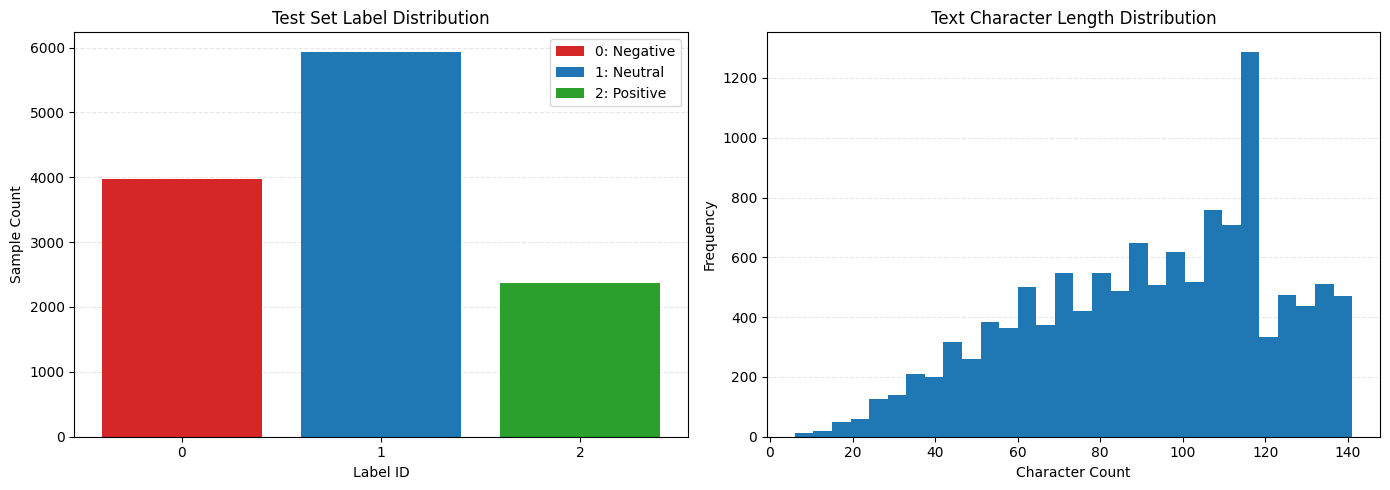

==== Text Length Statistics ====
count    12284.000000
mean        91.348095
std         29.973303
min          6.000000
25%         69.000000
50%         95.000000
75%        115.000000
max        141.000000
Name: text_length, dtype: float64


In [5]:
import matplotlib.pyplot as plt

df_test_eda = df_test.copy()
df_test_eda["text_length"] = df_test_eda["text"].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution bar chart
label_counts = df_test_eda["label"].value_counts().sort_index()
colors = ["#d62728", "#1f77b4", "#2ca02c"]
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_title("Test Set Label Distribution")
axes[0].set_xlabel("Label ID")
axes[0].set_xticks([0,1,2])
axes[0].legend(bars, ["0: Negative","1: Neutral","2: Positive"], loc="upper right")
axes[0].set_ylabel("Sample Count")
axes[0].grid(axis="y", alpha=0.3, linestyle="--")
axes[0].set_axisbelow(True)

# Text length histogram
axes[1].hist(df_test_eda["text_length"], bins=30)
axes[1].set_title("Text Character Length Distribution")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")
axes[1].grid(axis="y", alpha=0.3, linestyle="--")
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

print("==== Text Length Statistics ====")
print(df_test_eda["text_length"].describe())

## Part5: Data Cleaning

In [32]:
import re

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+|https\S+", "", text, flags=re.MULTILINE)
    # Remove user mentions @user
    text = re.sub(r"@\w+", "", text)
    # Remove hashtag symbol, retain word content
    text = re.sub(r"#(\w+)", r"\1", text)
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_clean = df_test_eda.copy()
df_clean["cleaned_text"] = df_clean["text"].apply(clean_text)
df_clean["is_modified"] = df_clean["text"] != df_clean["cleaned_text"]

print("====== Text Cleaning Summary ======")
total_records = len(df_clean)
modified_count = df_clean["is_modified"].sum()
modified_ratio = modified_count / total_records
print(f"Total records: {total_records}")
print(f"Modified records: {modified_count} ({modified_ratio:.2%})")

print("\n====== Cleaning Sample Comparison ======")
sample_compare = df_clean[df_clean["is_modified"]][["text", "cleaned_text"]].head(5)
print(sample_compare)

====== Text Cleaning Summary ======
Total records: 12284
Modified records: 8669 (70.57%)

====== Cleaning Sample Comparison ======
                                                text  \
0  @user @user what do these '1/2 naked pics' hav...   
2  @user @user That's coming, but I think the vic...   
3  I think I may be finally in with the in crowd ...   
4  @user Wow,first Hugo Chavez and now Fidel Cast...   
7  Twitter's #ThankYouObama Shows Heartfelt Grati...   

                                        cleaned_text  
0  what do these '1/2 naked pics' have to do with...  
2  That's coming, but I think the victims are goi...  
3  I think I may be finally in with the in crowd ...  
4  Wow,first Hugo Chavez and now Fidel Castro. Da...  
7  Twitter's ThankYouObama Shows Heartfelt Gratit...  


## Part6: Create Metadata

**Metadata list**
- **mention_count:**    how many @user observed
- **hash_count:**       how many #
- **has_url:**          0/1
- **has_emoji:**        0/1
- **text_length_bin:**  short/medium/long

In [33]:
import re

# emoji regex pattern
emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
                           "]+", flags=re.UNICODE)

def generate_metadata(row):
    raw = row["text"]
    clean = row["cleaned_text"]
    char_len = len(clean)
    # @
    mention_count = raw.count("@user")
    # #
    hash_count = raw.count("#")
    # URL
    has_url = 1 if re.search(r"http\S+|www\.\S+", raw) else 0
    # emoji
    has_emoji = 1 if emoji_pattern.search(raw) else 0
    # text length
    if char_len < 20:
        text_length_bin = "short"
    elif char_len <= 100:
        text_length_bin = "medium"
    else:
        text_length_bin = "long"

    return mention_count, hash_count, has_url, has_emoji, text_length_bin


meta_cols = ["mention_count","hash_count","has_url","has_emoji","text_length_bin"]
df_meta = df_clean.copy()
df_meta[meta_cols] = df_meta.apply(lambda r: generate_metadata(r), axis=1, result_type="expand")

print("\n====== How many Mentions ======")
mention_count = (df_meta["mention_count"] > 0).sum()
print(f"Number of records with mentions: {mention_count} out of {len(df_meta)} ({mention_count / len(df_meta):.2%})")

print("\n====== How many Hashtags ======")
hashtag_count = (df_meta["hash_count"] > 0).sum()
print(f"Number of records with hashtags: {hashtag_count} out of {len(df_meta)} ({hashtag_count / len(df_meta):.2%})")

print("\n====== URL Presence Summary ======")
url_count = df_meta["has_url"].sum()
print(f"Number of records with URLs: {url_count} out of {len(df_meta)} ({url_count / len(df_meta):.2%})")

print("\n====== Emoji Presence Summary ======")
emoji_count = df_meta["has_emoji"].sum()
print(f"Number of records with emojis: {emoji_count} out of {len(df_meta)} ({emoji_count / len(df_meta):.2%})")

print("\n====== Length Bin Distribution ======")
print(df_meta["text_length_bin"].value_counts())


====== How many Mentions ======
Number of records with mentions: 4848 out of 12284 (39.47%)

====== How many Hashtags ======
Number of records with hashtags: 4833 out of 12284 (39.34%)

====== URL Presence Summary ======
Number of records with URLs: 377 out of 12284 (3.07%)

====== Emoji Presence Summary ======
Number of records with emojis: 709 out of 12284 (5.77%)

====== Length Bin Distribution ======
text_length_bin
medium    7620
long      4510
short      154
Name: count, dtype: int64


## Part7: Weights & Biases Initial Test & Log Metadata Table

In [25]:
import wandb

# login to W&B
if not wandb.api.api_key:
    wandb.login(key="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")

# Initialize W&B run
wandb_run = wandb.init(
    project="KKU3S-Sentiment-M1",
    name="Metadata_Dataset_Log_Test",
    notes="Log raw test set + 5 metadata columns for final milestone data slicing"
)

table_columns = [
    "text",
    "cleaned_text",
    "label",
    "mention_count",
    "hash_count",
    "has_url",
    "has_emoji",
    "text_length_bin"
]

dataset_wb_table = wandb.Table(
    columns=table_columns,
    data=df_meta[table_columns].values.tolist()
)
wandb.log({"test_dataset_with_metadata": dataset_wb_table})

total_samples = len(df_meta)
summary_stats = {
    "ratio_has_mention": (df_meta["mention_count"] > 0).mean(),
    "ratio_has_hashtag": (df_meta["hash_count"] > 0).mean(),
    "ratio_has_url": df_meta["has_url"].mean(),
    "ratio_has_emoji": df_meta["has_emoji"].mean(),
    "ratio_bin_short": (df_meta["text_length_bin"] == "short").sum() / total_samples,
    "ratio_bin_medium": (df_meta["text_length_bin"] == "medium").sum() / total_samples,
    "ratio_bin_long": (df_meta["text_length_bin"] == "long").sum() / total_samples
}
wandb_run.summary.update(summary_stats)

# Finish run
wandb_run.finish()

print("W&B logging completed.")

ratio_bin_long,0.44741
ratio_bin_medium,0.54624
ratio_bin_short,0.00635
ratio_has_emoji,0.05772
ratio_has_hashtag,0.39344
ratio_has_mention,0.39466
ratio_has_url,0.03069


W&B logging completed.


## Part8: Load Models

In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
MAX_SEQ_LEN = 128
LABEL_MAPPING = {0:"negative",1:"neutral",2:"positive"}

# model list
model_list = {
    "base_roberta": "cardiffnlp/twitter-roberta-base-sentiment-latest",   
    "prod_gpt2": "LYTinn/gpt2-finetuning-sentiment-model-3000-samples",   
    "cand_xlm_roberta": "cardiffnlp/twitter-xlm-roberta-base-sentiment", 
    "cand_bertweet": "finiteautomata/bertweet-base-sentiment-analysis"  
}


# Load models and tokenizers
loaded_models = {}

print(f"Device: {DEVICE}")
for model_key, model_name in model_list.items():
    print(f"Loading {model_key} : {model_name}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    
    # GPT2 model does not have a pad_token by default, so we need to set it
    if model_key == "prod_gpt2":
        eos_str = "<|endoftext|>"
        tokenizer.pad_token = eos_str
        model.config.pad_token_id = tokenizer.convert_tokens_to_ids(eos_str)

    model.to(DEVICE)
    model.eval()
    loaded_models[model_key] = {"tokenizer":tokenizer, "model":model}
    print(f"--> {model_key} pad_token = {tokenizer.pad_token}, pad_token_id = {tokenizer.pad_token_id}")

print("All models and tokenizers loaded completed.")

Device: cuda
Loading base_roberta : cardiffnlp/twitter-roberta-base-sentiment-latest


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

--> cand_bertweet pad_token = <pad>, pad_token_id = 1
All models and tokenizers loaded completed.


model.safetensors: reconstructing file:   0%|          |  0.00B /  540MB            

model.safetensors: downloading bytes:           |  0.00B            

## Part9: Model Inference

In [34]:
def run_model_inference(model_dict, text_list):
    tokenizer = model_dict["tokenizer"]
    model = model_dict["model"]

    pred_ids = []
    pred_conf = []
    
    for start_idx in range(0, len(text_list), BATCH_SIZE):
        batch_text = text_list[start_idx: start_idx + BATCH_SIZE]
        inputs = tokenizer(
            batch_text,
            truncation=True,
            padding="max_length",
            max_length=MAX_SEQ_LEN,
            return_tensors="pt"
        ).to(DEVICE)
        
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
            conf_scores, predictions = torch.max(probs, dim=-1)
        
        pred_ids.extend(predictions.cpu().numpy())
        pred_conf.extend(conf_scores.cpu().numpy())
    return pred_ids, pred_conf

# inference input texts
infer_texts = df_meta["cleaned_text"].tolist()
infer_results = {}

# inference for each model
for key, item in loaded_models.items():
    print(f"Part9 Inference: Running {key} ...")
    p_ids, p_conf = run_model_inference(item, infer_texts)
    infer_results[key] = {"pred_ids": p_ids, "conf": p_conf}

print("All model inference finished.")

Part9 Inference: Running base_roberta ...
Part9 Inference: Running prod_gpt2 ...
Part9 Inference: Running cand_xlm_roberta ...
Part9 Inference: Running cand_bertweet ...
All model inference finished.


## Part10: Inference Result Preview

In [35]:
import numpy as np

print("==== Check unique predicted labels for each model ====")
for key, res in infer_results.items():
    # check unique predicted labels
    preds = np.unique(res["pred_ids"])
    print(f"{key} unique predicted ids: {sorted(preds)}")
    # update df_meta
    df_meta[f"pred_{key}"] = res["pred_ids"]
    df_meta[f"conf_{key}"] = res["conf"]


==== Check unique predicted labels for each model ====
base_roberta unique predicted ids: [np.int64(0), np.int64(1), np.int64(2)]
prod_gpt2 unique predicted ids: [np.int64(0), np.int64(1)]
cand_xlm_roberta unique predicted ids: [np.int64(0), np.int64(1), np.int64(2)]
cand_bertweet unique predicted ids: [np.int64(0), np.int64(1), np.int64(2)]


## Issues and Discussion

### Official Label Mapping Standards

All model label systems are verified against their official Hugging Face documentation:
1. **base_roberta** (`cardiffnlp/twitter-roberta-base-sentiment-latest`)
   - Native labels: 0 → negative, 1 → neutral, 2 → positive
   - Official source: [https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest](https://link.wtturl.cn/?target=https%3A%2F%2Fhuggingface.co%2Fcardiffnlp%2Ftwitter-roberta-base-sentiment-latest&scene=im&aid=582478&lang=zh)
2. **cand_xlm_roberta** (`cardiffnlp/twitter-xlm-roberta-base-sentiment`)
   - Native labels: 0 → Negative, 1 → Neutral, 2 → Positive
   - Official source: [https://huggingface.co/cardiffnlp/twitter-xlm-roberta-base-sentiment](https://link.wtturl.cn/?target=https%3A%2F%2Fhuggingface.co%2Fcardiffnlp%2Ftwitter-xlm-roberta-base-sentiment&scene=im&aid=582478&lang=zh)
3. **cand_bertweet** (`finiteautomata/bertweet-base-sentiment-analysis`)
   - Native labels: 0 → NEG, 1 → NEU, 2 → POS
   - Official source: [https://huggingface.co/finiteautomata/bertweet-base-sentiment-analysis](https://link.wtturl.cn/?target=https%3A%2F%2Fhuggingface.co%2Ffiniteautomata%2Fbertweet-base-sentiment-analysis&scene=im&aid=582478&lang=zh)
4. **prod_gpt2** (`LYTinn/gpt2-finetuning-sentiment-model-3000-samples`)
   - Official note: No explicit id-to-label text on the model card.
   - Verifiable facts:
     - Trained on the IMDB dataset, a standard binary sentiment task (negative / positive only, no neutral class)
     - Inference output contains only 2 unique label IDs (0 and 1), consistent with binary classification
   - Mapping convention used in this project: 0 → Negative, 1 → Positive
   - Official source: [https://huggingface.co/LYTinn/gpt2-finetuning-sentiment-model-3000-samples](https://link.wtturl.cn/?target=https%3A%2F%2Fhuggingface.co%2FLYTinn%2Fgpt2-finetuning-sentiment-model-3000-samples&scene=im&aid=582478&lang=zh)

The three 3-class models share identical numerical label semantics fully aligned with the TweetEval benchmark.

### Identified Issues

**ssue: Label space mismatch between production baseline and benchmark**
`prod_gpt2` is a binary classification model with no neutral class. It cannot be directly compared with the 3-class benchmark dataset and the other 3-class models on the full test set. Direct full-dataset evaluation is methodologically unfair and invalid.

### Selected Solution

1. All models are evaluated exclusively on the Negative / Positive subset as the unified primary benchmark, using binary F1-score as the core ranking metric for fair head-to-head comparison.
2. Adopt a two-tier evaluation framework:
   - **Primary ranking**: Binary performance of all 4 models, used as the core basis for model selection.
   - **Supplementary analysis**: 3-class full-set metrics (neutral-class performance, macro-F1) are calculated separately for the three 3-class models, to demonstrate extended capability beyond the current production version.






## Part11: Standardize Inference Output Data

In [36]:
import pandas as pd

def align_label(model_name, raw_pred):
    if pd.isna(raw_pred):
        return -1
    raw_pred = int(raw_pred)
    
    if model_name == "prod_gpt2":
        # Align binary output to benchmark ID: 0→neg, 1→pos
        return 0 if raw_pred == 0 else 2 if raw_pred == 1 else -1
    else:
        # 3-class models already match benchmark, return as-is
        return raw_pred

eval_model_list = ["prod_gpt2", "base_roberta", "cand_xlm_roberta", "cand_bertweet"]

for model in eval_model_list:
    df_meta[f"pred_std_{model}"] = df_meta[f"pred_{model}"].apply(lambda x: align_label(model, x))

print("Label alignment completed.")


Label alignment completed.


## Part12: Result Evaluation

In [37]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

eval_model_list = ["prod_gpt2", "base_roberta", "cand_xlm_roberta", "cand_bertweet"]
result_all = []

y_true = df_meta["label"].copy()

for model in eval_model_list:
    col_std = f"pred_std_{model}"
    y_pred = df_meta[col_std].copy()

    print(f"\n========== Model: {model} ==========")
    print("Prediction distribution:\n", y_pred.value_counts().sort_index())

    prec_arr = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec_arr  = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_arr   = f1_score(y_true, y_pred, average=None, zero_division=0)

    class_info = [
        {"class_id":0, "class_name":"Negative"},
        {"class_id":1, "class_name":"Neutral"},
        {"class_id":2, "class_name":"Positive"},
    ]

    for idx, cls in enumerate(class_info):
        cid = cls["class_id"]
        cname = cls["class_name"]
        if model == "prod_gpt2" and cid == 1:
            result_all.append({
                "model": model,
                "class_id": cid,
                "class_name": cname,
                "precision": None,
                "recall": None,
                "f1_score": None
            })
            continue
        result_all.append({
            "model": model,
            "class_id": cid,
            "class_name": cname,
            "precision": round(prec_arr[idx],4),
            "recall": round(rec_arr[idx],4),
            "f1_score": round(f1_arr[idx],4)
        })

df_all = pd.DataFrame(result_all)


========== Model: prod_gpt2 ==========
Prediction distribution:
 pred_std_prod_gpt2
0    6695
2    5589
Name: count, dtype: int64

========== Model: base_roberta ==========
Prediction distribution:
 pred_std_base_roberta
0    4705
1    5180
2    2399
Name: count, dtype: int64

========== Model: cand_xlm_roberta ==========
Prediction distribution:
 pred_std_cand_xlm_roberta
0    5622
1    4333
2    2329
Name: count, dtype: int64

========== Model: cand_bertweet ==========
Prediction distribution:
 pred_std_cand_bertweet
0    4544
1    5234
2    2506
Name: count, dtype: int64


In [43]:
df_neg = df_all[df_all["class_id"] == 0].copy()
print("\n===== Table1: Negative Class Performance (all 4 models) =====")
print(df_neg.to_markdown(index=False, floatfmt=".4f"))

df_pos = df_all[df_all["class_id"] == 2].copy()
print("\n===== Table2: Positive Class Performance (all 4 models) =====")
print(df_pos.to_markdown(index=False, floatfmt=".4f"))

df_neu = df_all[(df_all["class_id"] == 1) & (df_all["model"] != "prod_gpt2")].copy()
print("\n===== Table3: Neutral Class Performance (3‑class candidates only) =====")
print(df_neu.to_markdown(index=False, floatfmt=".4f"))


===== Table1: Negative Class Performance (all 4 models) =====
| model            |   class_id | class_name   |   precision |   recall |   f1_score |
|:-----------------|-----------:|:-------------|------------:|---------:|-----------:|
| prod_gpt2        |          0 | Negative     |      0.3276 |   0.5521 |     0.4112 |
| base_roberta     |          0 | Negative     |      0.6833 |   0.8094 |     0.7410 |
| cand_xlm_roberta |          0 | Negative     |      0.6154 |   0.8711 |     0.7213 |
| cand_bertweet    |          0 | Negative     |      0.7000 |   0.8009 |     0.7471 |

===== Table2: Positive Class Performance (all 4 models) =====
| model            |   class_id | class_name   |   precision |   recall |   f1_score |
|:-----------------|-----------:|:-------------|------------:|---------:|-----------:|
| prod_gpt2        |          2 | Positive     |      0.2237 |   0.5263 |     0.3139 |
| base_roberta     |          2 | Positive     |      0.7140 |   0.7213 |     0.7176 |
| ca